# CNN 实战：训练 MNIST 手写数字识别

这一章把前面学的 CNN 和训练流程结合起来，用一个完整的 CNN 模型训练 MNIST 数据集，目标是识别 0-9 手写数字。

### 流程回顾

1. 准备数据（Dataset + DataLoader）
2. 定义 CNN 模型
3. 定义损失函数和优化器
4. 训练循环
5. 评估模型效果

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"设备: {device}")

设备: cuda


## 1. 准备数据

MNIST 数据集：60000 张训练图片 + 10000 张测试图片，每张 28x28 灰度图，标签是 0-9。

transforms.ToTensor() 会把像素值从 0-255 归一化到 0-1。

In [4]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"训练集: {len(train_dataset)} 张图片")
print(f"测试集: {len(test_dataset)} 张图片")
print(f"训练 batch 数: {len(train_loader)}")

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.79MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 80.0kB/s]
100%|██████████| 1.65M/1.65M [00:03<00:00, 480kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.80MB/s]

训练集: 60000 张图片
测试集: 10000 张图片
训练 batch 数: 938


## 2. 定义 CNN 模型

结构：
- conv1: 1 通道 → 32 通道，3x3 卷积 + ReLU + MaxPool
- conv2: 32 通道 → 64 通道，3x3 卷积 + ReLU + MaxPool
- 展平后接全连接层做分类

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  # 1→32 通道
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 28x28 → 14x14
            nn.Conv2d(32, 64, 3, padding=1),  # 32→64 通道
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 14x14 → 7x7
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)          # 提取特征
        x = x.view(x.size(0), -1)     # 展平
        x = self.classifier(x)        # 分类
        return x

model = CNN().to(device)
print(model)
print(f"\n参数量: {sum(p.numel() for p in model.parameters()):,}")

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=3136, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)

参数量: 421,642


### 补充：nn.Sequential

刚才用到了 `nn.Sequential`，它是一个容器，把多个层按顺序串起来。相当于简化了 forward 里逐层调用的写法：

```python
# 不用 Sequential 的写法
self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
self.relu1 = nn.ReLU()
self.pool1 = nn.MaxPool2d(2)

def forward(self, x):
    x = self.pool1(self.relu1(self.conv1(x)))

# 用 Sequential 的写法
self.features = nn.Sequential(
    nn.Conv2d(1, 32, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
)

def forward(self, x):
    x = self.features(x)  # 一行搞定
```

当层很多时，Sequential 让代码更简洁。

## 3. 损失函数和优化器

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## 4. 训练循环

每个 epoch：
1. 训练：遍历训练集，前向传播 → 算损失 → 反向传播 → 更新参数
2. 验证：在测试集上计算准确率（不更新参数）

In [7]:
num_epochs = 10
train_losses = []
test_accs = []

for epoch in range(num_epochs):
    # === 训练 ===
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # === 验证 ===
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch).argmax(dim=1)
            correct += (pred == y_batch).sum().item()
            total += y_batch.size(0)

    acc = correct / total * 100
    test_accs.append(acc)
    print(f"Epoch [{epoch+1}/{num_epochs}] 训练损失: {avg_loss:.4f} 测试准确率: {acc:.2f}%")

Epoch [1/10] 训练损失: 0.1916 测试准确率: 97.89%
Epoch [2/10] 训练损失: 0.0497 测试准确率: 98.88%
Epoch [3/10] 训练损失: 0.0343 测试准确率: 98.82%
Epoch [4/10] 训练损失: 0.0265 测试准确率: 99.01%
Epoch [5/10] 训练损失: 0.0189 测试准确率: 99.20%
Epoch [6/10] 训练损失: 0.0174 测试准确率: 99.10%
Epoch [7/10] 训练损失: 0.0126 测试准确率: 99.20%
Epoch [8/10] 训练损失: 0.0102 测试准确率: 99.07%
Epoch [9/10] 训练损失: 0.0090 测试准确率: 98.95%
Epoch [10/10] 训练损失: 0.0082 测试准确率: 99.12%


## 5. 可视化训练过程

画出训练损失和测试准确率的变化曲线，观察模型是否在学习。

/tmp/ipykernel_29997/429470675.py:15: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29997/429470675.py:15: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29997/429470675.py:15: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29997/429470675.py:15: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29997/429470675.py:15: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29997/429470675.py:15: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29997/429470675.py:15: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}

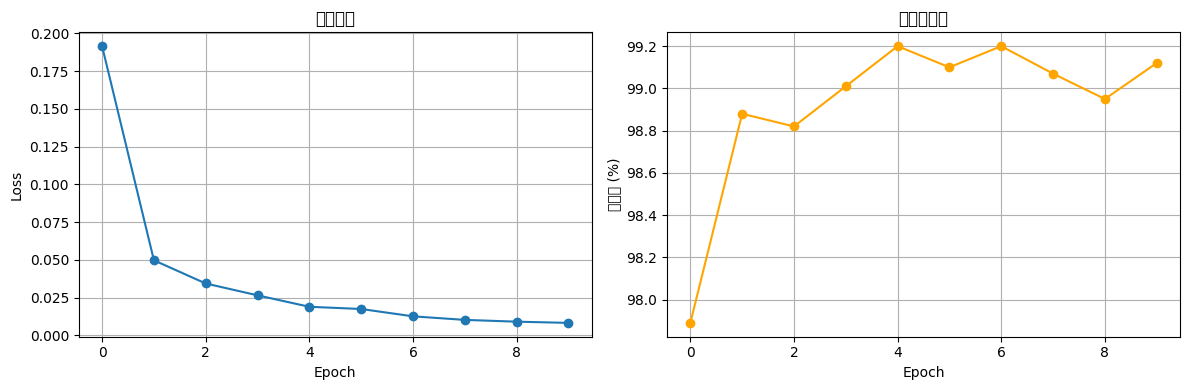

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, marker='o')
ax1.set_title('训练损失')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(test_accs, marker='o', color='orange')
ax2.set_title('测试准确率')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('准确率 (%)')
ax2.grid(True)

plt.tight_layout()
plt.show()

## 6. 预测可视化

从测试集随机取一些图片，看看模型的预测结果。

/tmp/ipykernel_29997/2334607552.py:22: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29997/2334607552.py:22: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29997/2334607552.py:22: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29997/2334607552.py:22: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29997/2334607552.py:22: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29997/2334607552.py:22: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29997/2334607552.py:22: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PAREN

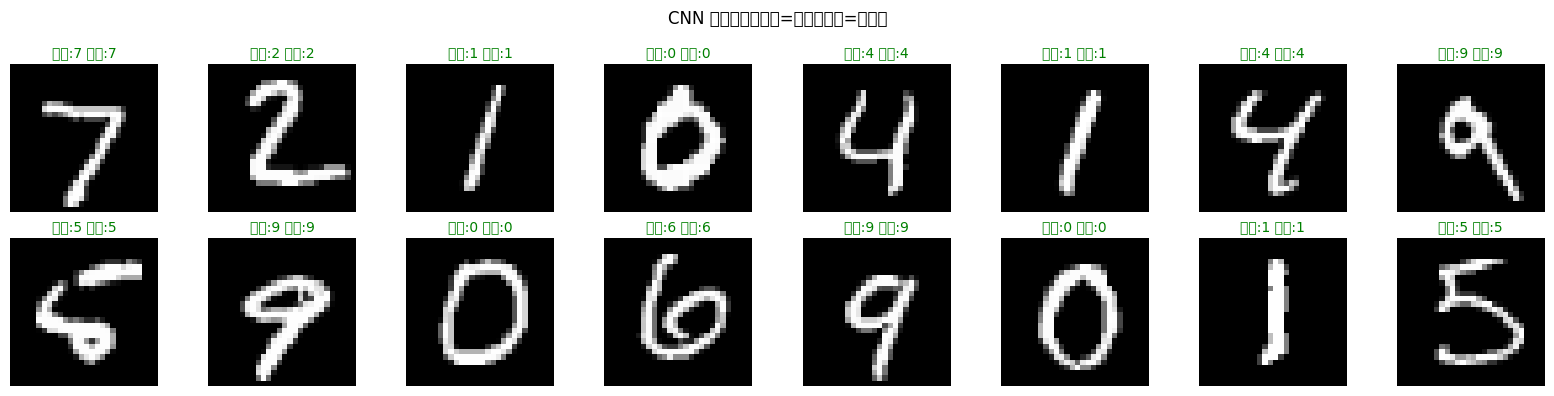

In [9]:
model.eval()

# 取一个 batch 的测试数据
X_test, y_test = next(iter(test_loader))
X_test, y_test = X_test.to(device), y_test.to(device)

with torch.no_grad():
    preds = model(X_test).argmax(dim=1)

# 可视化前16张
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(16):
    ax = axes[i // 8][i % 8]
    img = X_test[i].cpu().squeeze()
    ax.imshow(img, cmap='gray')
    true_label = y_test[i].item()
    pred_label = preds[i].item()
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"真实:{true_label} 预测:{pred_label}", fontsize=10, color=color)
    ax.axis('off')
plt.suptitle('CNN 预测结果（绿色=正确，红色=错误）')
plt.tight_layout()
plt.show()

## 7. 保存模型

In [10]:
# 保存训练好的模型参数
torch.save(model.state_dict(), 'mnist_cnn.pth')
print("模型已保存到 mnist_cnn.pth")

# 加载示例
# loaded_model = CNN().to(device)
# loaded_model.load_state_dict(torch.load('mnist_cnn.pth'))
# loaded_model.eval()

模型已保存到 mnist_cnn.pth
